# 08 — Session Filter

## Concept
XAUUSDT price behaviour differs dramatically by market session:

| Session       | UTC Hours  | Characteristics                          |
|---------------|-----------|------------------------------------------|
| Asia          | 00–09      | Low volume, choppy, OBs fill quickly     |
| London        | 07–12      | Strong directional moves, clean OBs      |
| London/NY     | 12–16      | Highest liquidity, best OB reactions     |
| New York      | 16–21      | Continuation of London + data events     |
| Off-hours     | 21–00      | Thin, avoid                              |

## Hypothesis
Restricting OB signals to London + NY hours should:
- Remove many low-quality Asian session false signals
- Improve win rate at the cost of some trade frequency

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import add_candle_features
from strategy.filters.session import add_session_column, TradingSession, get_session
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 6)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_session_column(add_candle_features(m5.sort_index()))

session_counts = m5['session'].value_counts()
print('Bar count by session:')
print(session_counts)

Bar count by session:
session
asia         5761
london       4140
new_york     4137
london_ny    3312
off_hours    2448
Name: count, dtype: int64


In [2]:
# ── Session performance analysis ───────────────────────────────────────────
m5['candle_return'] = (m5['close'] - m5['open']).abs()
m5['direction']     = (m5['close'] > m5['open']).map({True: 'bull', False: 'bear'})

session_stats = m5.groupby('session').agg(
    bars          = ('close', 'count'),
    avg_range     = ('candle_return', 'mean'),
    avg_volume    = ('volume', 'mean'),
    avg_atr       = ('atr', 'mean'),
).round(4)

print('\nSession statistics:')
print(session_stats)


Session statistics:
           bars  avg_range  avg_volume  avg_atr
session                                        
asia       5761     2.4257     15.7868   4.2214
london     4140     2.3984     19.9224   4.2757
london_ny  3312     3.3154     29.9524   6.1015
new_york   4137     2.2548     14.3782   4.1884
off_hours  2448     1.9548     15.4779   3.4331


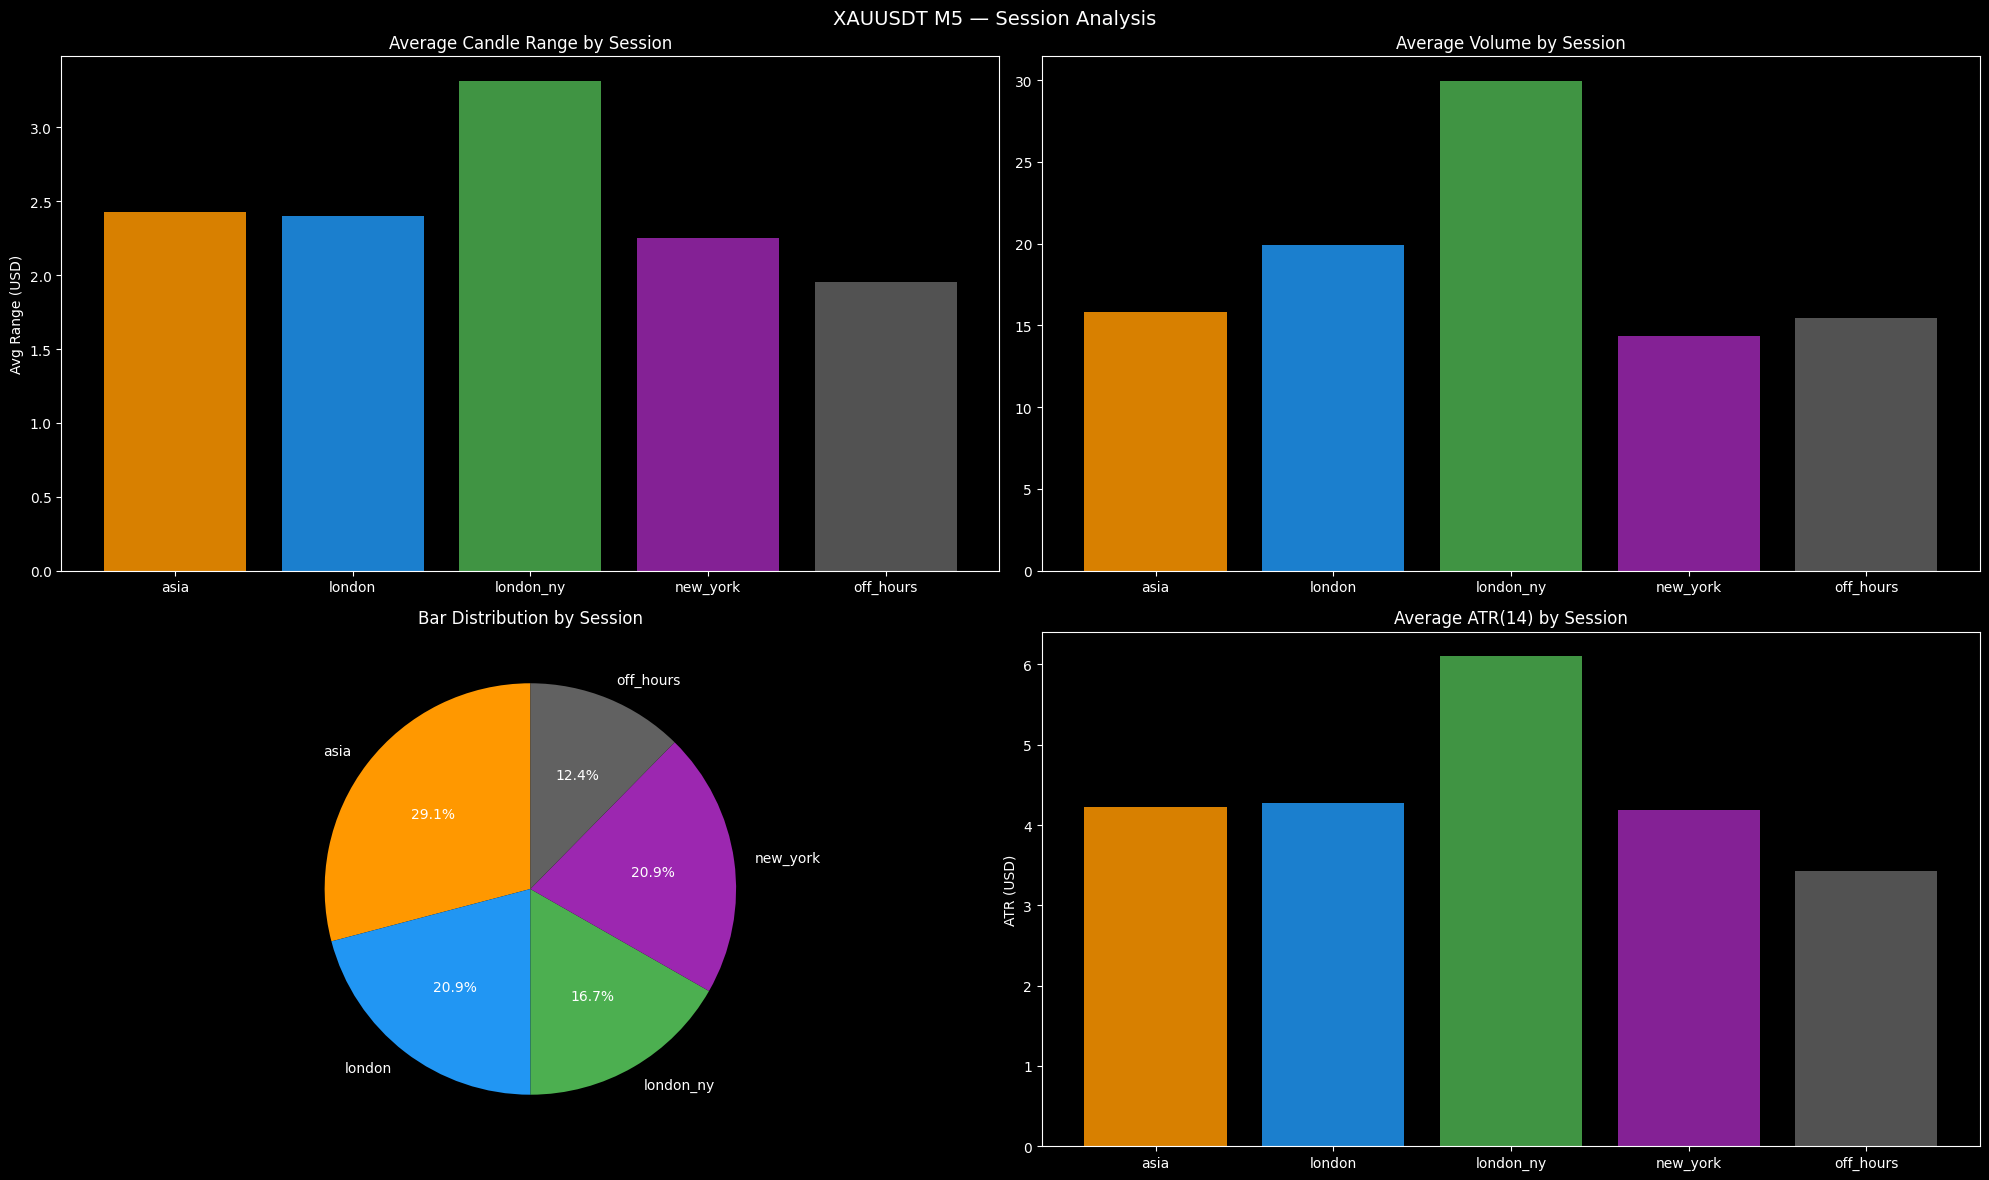

In [3]:
# ── Session visualization ──────────────────────────────────────────────────
session_colors = {
    'asia'      : '#FF9800',
    'london'    : '#2196F3',
    'london_ny' : '#4CAF50',
    'new_york'  : '#9C27B0',
    'off_hours' : '#616161',
}

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Average range by session
bars = list(session_stats.index)
colors = [session_colors.get(s, 'grey') for s in bars]
axes[0,0].bar(bars, session_stats['avg_range'], color=colors, alpha=0.85)
axes[0,0].set_title('Average Candle Range by Session')
axes[0,0].set_ylabel('Avg Range (USD)')

# Average volume by session
axes[0,1].bar(bars, session_stats['avg_volume'], color=colors, alpha=0.85)
axes[0,1].set_title('Average Volume by Session')

# Bar count by session
axes[1,0].pie(session_stats['bars'], labels=session_stats.index,
              colors=[session_colors.get(s,'grey') for s in session_stats.index],
              autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Bar Distribution by Session')

# ATR by session
axes[1,1].bar(bars, session_stats['avg_atr'], color=colors, alpha=0.85)
axes[1,1].set_title('Average ATR(14) by Session')
axes[1,1].set_ylabel('ATR (USD)')

plt.suptitle(f'{SYMBOL} M5 — Session Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# ── OB signals by session ──────────────────────────────────────────────────
cfg_base    = OBSignalConfig(rr=2.0)
cfg_session = OBSignalConfig(rr=2.0, session_filter_enabled=True,
                             allow_london=True, allow_new_york=True,
                             allow_overlap=True, allow_asia=False)

sigs_base    = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_base)
sigs_session = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_session)
sigs_pass    = get_passed_signals(sigs_session)

print(f'Baseline signals  : {len(sigs_base)}')
print(f'Session-filtered  : {len(sigs_pass)}')
pct = (1 - len(sigs_pass) / max(len(sigs_base), 1)) * 100
print(f'Reduction         : {pct:.1f}%')

if not sigs_session.empty and 'session' in sigs_session.columns:
    print('\nSignals by session (before filter):')
    print(sigs_session.groupby('session').size())
    print('\nSignals by session (after filter):')
    print(sigs_pass.groupby('session').size() if not sigs_pass.empty else 'None passed')

Baseline signals  : 290
Session-filtered  : 191
Reduction         : 34.1%

Signals by session (before filter):
session
asia         76
london       69
london_ny    71
new_york     51
off_hours    23
dtype: int64

Signals by session (after filter):
session
london       69
london_ny    71
new_york     51
dtype: int64
